In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [117]:
df=pd.read_csv("calories.csv")

In [118]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [120]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [121]:
df["Gender"].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

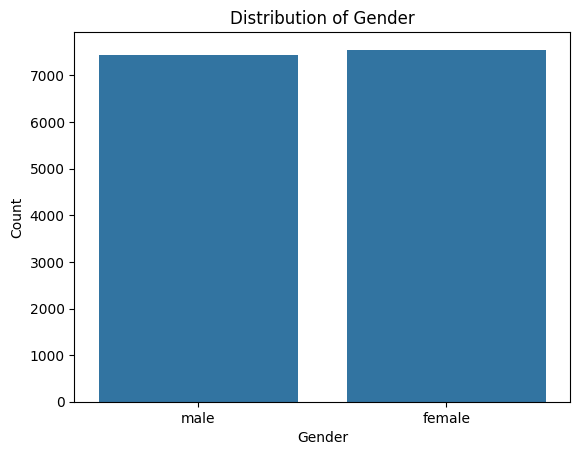

In [122]:
sns.countplot(data=df,x="Gender")
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Frequency')

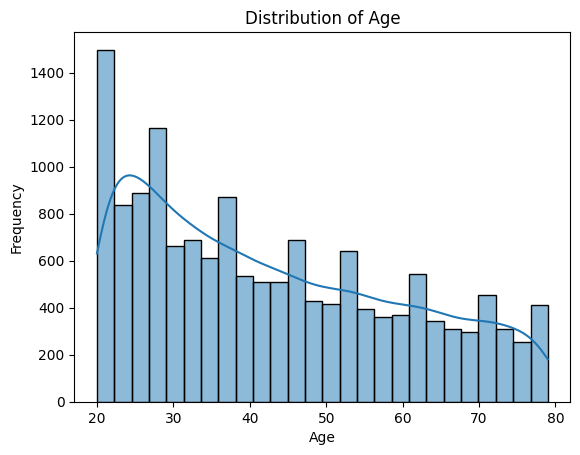

In [123]:
sns.histplot(df["Age"], kde=True)
plt.title('Distribution of Age')
plt.xlabel("Age")
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

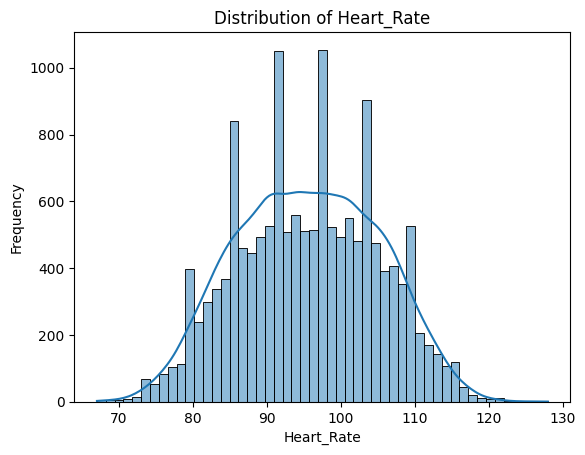

In [124]:
sns.histplot(df["Heart_Rate"], kde=True)
plt.title('Distribution of Heart_Rate')
plt.xlabel("Heart_Rate")
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

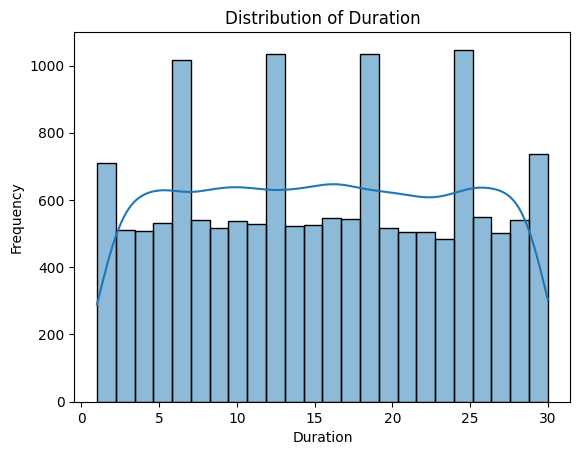

In [125]:
sns.histplot(df["Duration"], kde=True)
plt.title('Distribution of Duration')
plt.xlabel("Duration")
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

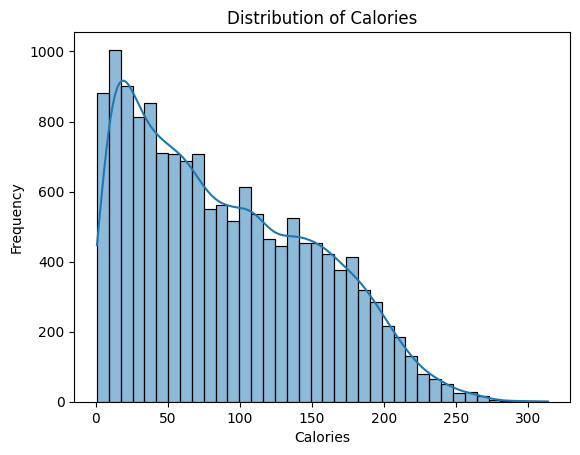

In [126]:
sns.histplot(df["Calories"], kde=True)
plt.title('Distribution of Calories')
plt.xlabel("Calories")
plt.ylabel('Frequency')

In [127]:
df["Calories"].describe()

count    15000.000000
mean        89.539533
std         62.456978
min          1.000000
25%         35.000000
50%         79.000000
75%        138.000000
max        314.000000
Name: Calories, dtype: float64

<Axes: xlabel='Gender', ylabel='Calories'>

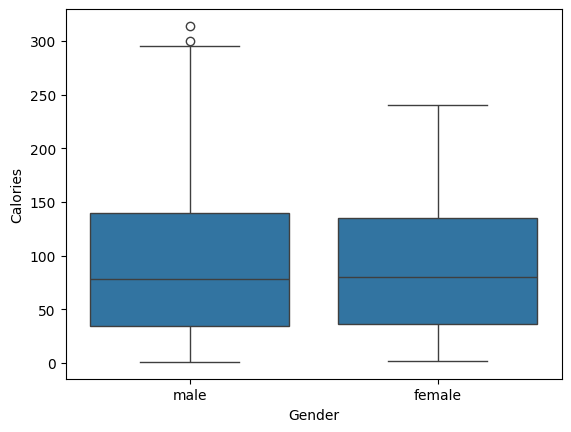

In [128]:
sns.boxplot(data=df,x="Gender",y="Calories")

In [129]:
df[df["Calories"]>291].value_counts()

User_ID   Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
10784322  male    75   178.0   76.0    29.0      120.0       40.8       295.0       1
13079051  male    75   199.0   103.0   28.0      123.0       40.5       314.0       1
17545969  male    69   193.0   90.0    29.0      121.0       41.1       300.0       1
17825244  male    65   189.0   98.0    27.0      125.0       40.9       295.0       1
Name: count, dtype: int64

<Axes: ylabel='Duration'>

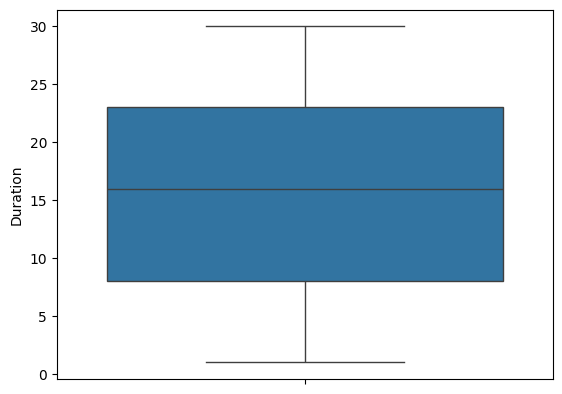

In [130]:
sns.boxplot(df["Duration"])

<Axes: ylabel='Body_Temp'>

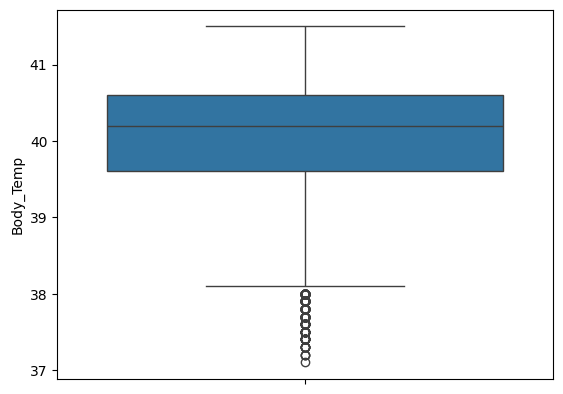

In [131]:
sns.boxplot(df["Body_Temp"])

<Axes: xlabel='Heart_Rate', ylabel='Calories'>

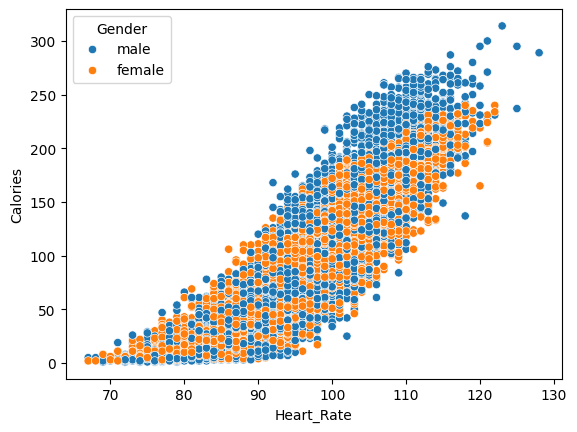

In [132]:
sns.scatterplot(data=df,x="Heart_Rate",y="Calories",hue="Gender")

<Axes: xlabel='Duration', ylabel='Calories'>

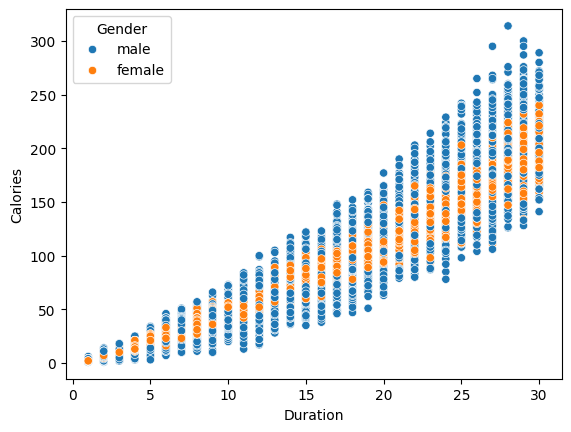

In [133]:
sns.scatterplot(data=df,x="Duration",y="Calories",hue="Gender")

In [134]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [135]:
numerical_features_to_clean = ['Calories', 'Duration', 'Heart_Rate', 'Body_Temp', 'Age', 'Height', 'Weight']

original_rows = df.shape[0]
print(f"Original number of rows: {original_rows}")

for feature in numerical_features_to_clean:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

Original number of rows: 15000


In [136]:
df.shape

(14611, 9)

In [137]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


<Axes: xlabel='Gender', ylabel='Calories'>

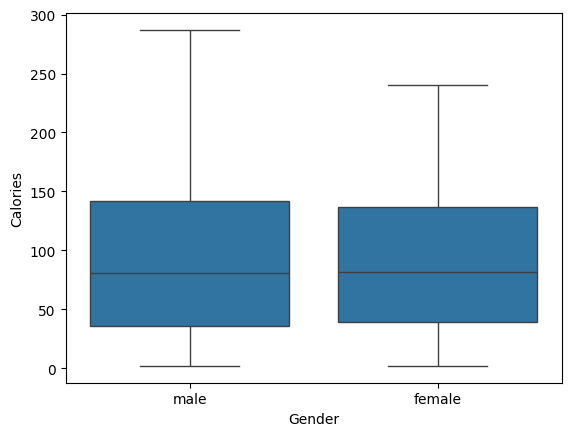

In [138]:
sns.boxplot(data=df,x="Gender",y="Calories")

<Axes: ylabel='Body_Temp'>

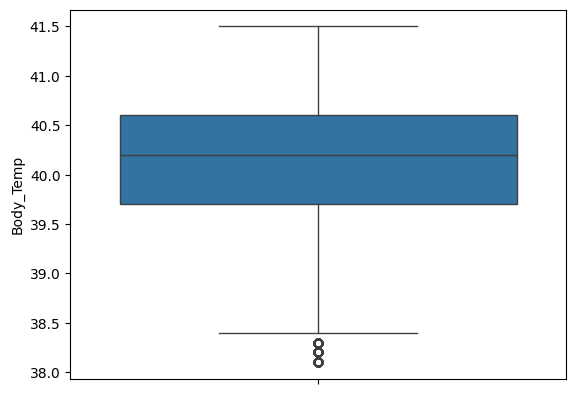

In [139]:
sns.boxplot(df["Body_Temp"])

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14611 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     14611 non-null  int64  
 1   Gender      14611 non-null  object 
 2   Age         14611 non-null  int64  
 3   Height      14611 non-null  float64
 4   Weight      14611 non-null  float64
 5   Duration    14611 non-null  float64
 6   Heart_Rate  14611 non-null  float64
 7   Body_Temp   14611 non-null  float64
 8   Calories    14611 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.1+ MB


In [141]:
df["Gender"]=df["Gender"].astype("category")

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14611 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   User_ID     14611 non-null  int64   
 1   Gender      14611 non-null  category
 2   Age         14611 non-null  int64   
 3   Height      14611 non-null  float64 
 4   Weight      14611 non-null  float64 
 5   Duration    14611 non-null  float64 
 6   Heart_Rate  14611 non-null  float64 
 7   Body_Temp   14611 non-null  float64 
 8   Calories    14611 non-null  float64 
dtypes: category(1), float64(6), int64(2)
memory usage: 1.0 MB


In [143]:
df["Gender"]=df["Gender"].map({"male":1,"female":0})

In [144]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,0,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,0,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,0,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,1,78,193.0,97.0,2.0,84.0,38.3,11.0


In [145]:
df=df.drop(["User_ID"],axis=1)

In [146]:
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...
14995,0,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,0,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,0,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,1,78,193.0,97.0,2.0,84.0,38.3,11.0


In [147]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [148]:
x=df.drop(["Calories"],axis=1)
y=df["Calories"]

In [149]:
x.shape

(14611, 7)

In [150]:
y.shape

(14611,)

In [151]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=80,test_size=0.2)

In [152]:
model.fit(x_train,y_train)

LinearRegression()

In [153]:
y_pred=model.predict(x_test)

In [154]:
y_pred

array([ 93.78875507,  38.9101541 , 116.20740114, ...,  15.59671349,
       158.51657257, 194.47505117])

In [163]:
c = model.intercept_
print(c)


472.42358213106826


In [168]:
for i in range(7):
    print(f"m{i} = {model.coef_[i]}")


m0 = -1.3311127315641043
m1 = 0.5058083503571449
m2 = -0.20081978935783507
m3 = 0.32122839718236734
m4 = 6.621857681016995
m5 = 2.015102352999802
m6 = -17.196029126254544


In [160]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_pred,y_test))

8.451013455399007


In [162]:
model.score(x_test,y_test)

0.9658016243608569

In [170]:
import pickle
pickle.dump(model,open("calorie_tracker.pkl","wb"))


In [171]:
min(df["Weight"])

38.0